# 🎯 Quiz 1.2:
### Name: Abon, Benedict Aldous A.
### Date: 7/21/26
### Section: CPE31S3
### Course: CPE 312

In the lesson notebook, we walked through all six stages of the ML process together, using
the Iris dataset. Now it's your turn to apply the **same six stages, independently**, to a
**new dataset**: the Wine dataset.

The Wine dataset contains chemical analysis results for 178 wines grown in the same region
of Italy, from **3 different cultivars (grape varieties)**. Your goal: given the chemical
measurements, predict which cultivar a wine belongs to.

**Rules for this activity:**
- Follow the 6-stage process, in order: Data Acquisition → Data Cleaning → Choose a Model → Train/Validate/Test → Model Evaluation → Model Deployment.
- Every `# TODO` marks something you need to write yourself. Read the guiding comments carefully — they tell you exactly what's expected.
- Markdown cells with **❓ Reflection Questions** need short written answers in the cell provided — these check your understanding, not just your code.
- You may look back at the lesson notebook for reference on syntax, but the logic should be your own.

Good luck! 🍷


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(7)

print("Libraries loaded.")


Libraries loaded.


---
## Stage 1: Data Acquisition

The Wine dataset is provided below (already loaded from scikit-learn, so you don't need to
write any file-loading code — just like Iris, it ships built into the library).


In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target  # 0, 1, or 2 -- the three cultivars

print(f"Acquired {df.shape[0]} records with {df.shape[1]-1} features each.")
df.head()


Acquired 178 records with 13 features each.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### ❓ Reflection Question 1
Look at `wine.feature_names` and `wine.target_names` below. In your own words, what problem
are we trying to solve here — and is it classification or regression? Why?

*(Double-click this cell and write your answer directly below the code output.)*


In [3]:
print("Features:", wine.feature_names)
print("Target classes:", wine.target_names)

# YOUR ANSWER HERE (as a Python comment or just leave this cell for reference):
# This problem is a _______ problem, because we are predicting _______.

# The problem is a classification problem, because we are predicting the three classes or types of wine based on their chemical contents and physical properties.


Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']


### Simulating messy data (provided for you)

Just like the lesson notebook, we'll deliberately mess up a copy of this data so Stage 2
has something real to clean. This part is provided — you don't need to write it.


In [4]:
messy_df = df.copy()

# Inject a missing value
messy_df.loc[15, 'alcohol'] = np.nan

# Inject an outlier (color_intensity should never realistically be 500)
messy_df.loc[40, 'color_intensity'] = 500.0

# Inject a duplicate row
messy_df = pd.concat([messy_df, messy_df.loc[[3]]], ignore_index=True)

print(f"Messy dataset shape: {messy_df.shape}")


Messy dataset shape: (179, 14)


---
## Stage 2: Data Cleaning (Pre-processing)

Now it's your turn. Using the techniques from the lesson notebook, complete the steps below.


In [5]:
# TODO 1: Check how many missing values exist in `messy_df`, per column.
# Hint: use .isnull().sum()

# YOUR CODE HERE

messy_df.isnull().sum()


,0
alcohol,1
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


<Axes: ylabel='color_intensity'>

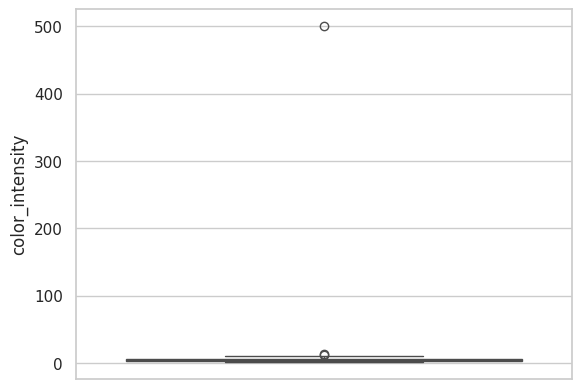

In [6]:
# TODO 2: Use a boxplot (or any visualization you like) to visually confirm the outlier
# in 'color_intensity'.
# Hint: sns.boxplot(y=messy_df['color_intensity'])

# YOUR CODE HERE

sns.boxplot(y=messy_df['color_intensity'])


In [7]:
# TODO 3: Check how many exact duplicate rows exist in `messy_df`.
# Hint: use .duplicated().sum()

# YOUR CODE HERE

messy_df.duplicated().sum()


np.int64(1)

In [8]:
print(messy_df.loc[15, 'alcohol'])

nan


In [9]:
# TODO 4: Now clean the data:
#   a) Fill the missing 'alcohol' value with the column's mean
#   b) Remove the row(s) where 'color_intensity' is unrealistically large (e.g. > 50)
#   c) Drop duplicate rows
#   d) Save your result into a new variable called `clean_df`
#   e) Print clean_df.shape and confirm there are no missing values left

# YOUR CODE HERE
clean_df = messy_df.copy()

# fill alcohol value
clean_df.fillna(clean_df['alcohol'].mean(), inplace=True)

# remove color intensity > 50
clean_df = clean_df[clean_df['color_intensity'] <= 50]

# drop duplicate rows
clean_df.drop_duplicates(inplace=True)

# save result as clean_df
print(clean_df)

# print clean_df.shape and confirm there are no missing values left
print(clean_df.shape)
clean_df.isnull().sum()

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


### ❓ Reflection Question 2
How many rows did you remove in total during cleaning? Why is it important to check for
duplicates *and* missing values *and* outliers — wouldn't checking for just one be enough?

- I removed a total of 2 rows from the dataframe during cleaning. Despite having few or more missing values and outliers, it is important to check for them since they can drastically affect the future processes, especially the output of the model. We must ensure that the data that we are using in the model is sufficient for training and must contain no inconsistencies.


---
## Stage 3: Choose a Model

We'll use a **Decision Tree** again, for consistency with the lesson notebook — but you need
to define your features (`X`) and target (`y`) from `clean_df`.


In [10]:
# TODO: Define X (all wine.feature_names columns) and y (the 'target' column) from clean_df

# YOUR CODE HERE
X = clean_df[wine.feature_names]
y = clean_df.target

print(f"Feature count: {X.shape[1] if X is not None else 'N/A'}")


Feature count: 13


### ❓ Reflection Question 3
This dataset has 13 features (much more than Iris's 4). Do you think that makes the modeling
problem easier or harder? What extra care might Stage 2 (cleaning) need with more features?

Compared to the machine learning process from the Iris dataset, the modeling problem now will be harder, because more features are being held into account by the decision tree algorithm. Before model training, the cleaning process must include validating columns that are important in the classification of wine. In other words, features that are not significant in their classification can be neglected, relying only on the important features. With this, less features will be considered by the algorithm.


---
## Stage 4: Training, Validation & Testing

Split your data into a **60% training / 20% validation / 20% test** split, just like the
lesson notebook (hint: this needs two calls to `train_test_split`, one after another).

Remember: `stratify=y` keeps the class proportions equal across all three sets.


In [11]:
# TODO: First split off the test set (20%), then split the remainder into train (75% of it) and validation (25% of it)

# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Training set:   {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set:       {len(X_test)} samples")


Training set:   105 samples
Validation set: 36 samples
Test set:       36 samples


In [12]:
# TODO: Try at least 4 different values of max_depth on the VALIDATION set (not the test set!)
# and print each one's accuracy. Then store the best-performing depth in `best_depth`.

# YOUR CODE HERE
best_depth = 4

# Tested depth - Accuracy
# 1 - 58.33%
# 2 - 86.11%
# 3 - 91.67%
# 4 - 91.67%
# 5 - 91.67%

In [13]:
# Model training (Validation)
val_model = DecisionTreeClassifier(max_depth=4, random_state=42)
val_model.fit(X_val, y_val)
print("Validation model has been trained on the training data.")
pred = val_model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f"Test Accuracy: {accuracy:.2%}")

Validation model has been trained on the training data.
Test Accuracy: 91.67%


In [14]:
# TODO: Train your final model using best_depth, on the TRAINING set only.

# YOUR CODE HERE
final_model = DecisionTreeClassifier(max_depth=4, random_state=42)
final_model.fit(X_train, y_train)
print("Final model has been trained on the training data.")
final_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, final_pred)
print(f"Test Accuracy: {accuracy:.2%}")

Final model has been trained on the training data.
Test Accuracy: 97.22%


---
## Stage 5: Model Evaluation

Now reveal the test set. Compute accuracy, precision, recall, F1-score, and a confusion matrix.


In [15]:
# TODO: Predict on X_test, then compute and print accuracy, precision, recall, and F1-score
# (use average='macro' for precision/recall/f1, same as the lesson notebook)

# YOUR CODE HERE
precision = precision_score(y_test, final_pred, average='macro')
recall = recall_score(y_test, final_pred, average='macro')
f1 = f1_score(y_test, final_pred, average='macro')

print(f"Precision (macro avg): {precision:.2%}")
print(f"Recall (macro avg):    {recall:.2%}")
print(f"F1-score (macro avg):  {f1:.2%}")


Precision (macro avg): 97.78%
Recall (macro avg):    97.22%
F1-score (macro avg):  97.40%


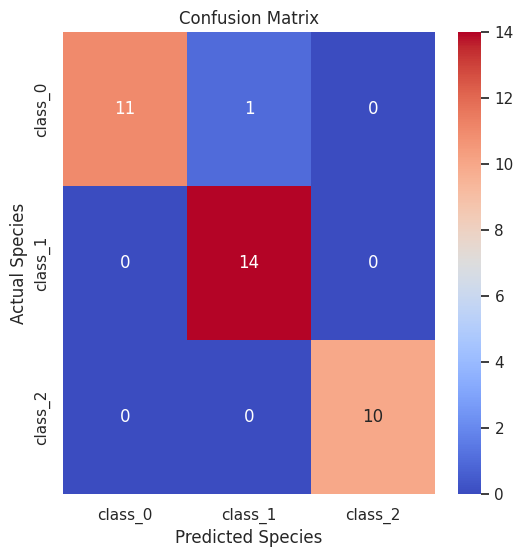

In [16]:
# TODO: Plot a confusion matrix for your test set predictions.
# Hint: use confusion_matrix() and sns.heatmap(), same pattern as the lesson notebook.
# Use wine.target_names for your axis labels.

# YOUR CODE HERE
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='coolwarm',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix')
plt.show()


### ❓ Reflection Question 4
Look at your confusion matrix. Which cultivar (if any) does your model confuse most often
with another? Take a guess at why that might be, based on what you know about the features.

Based on the results of the confusion matrix, the model confuse class 0 and class 1 with one another, because their intersection in the matrix show a value of one. It may be because of a data point that based its alcohol content on the average of all alcohol contents in the dataset. Apart from that, the model was able to distinguish the wine classes efficiently.

---
## ✅ Submission Checklist

Before you submit this notebook, confirm:

- [ ] All `# TODO` cells have working code (no `None` placeholders left)
- [ ] All 4 Reflection Questions are answered in their markdown cells
- [ ] The notebook runs top-to-bottom without errors (use **Kernel → Restart & Run All** to check!)
- [ ] Your confusion matrix and metrics are visible in the output
tested

**Great work completing the full ML process on your own dataset!** 🍷
